# Análise completa — varredura de batch size do KMNIST

Notebook reexecutável que lê os CSVs auditados da varredura `all_raw`,
sem augmentation e com 50 épocas por batch. Ele contém as 32 runs,
as 1.600 épocas, telemetria de hardware e métricas das 10 classes.

## TL;DR

- As **32 de 32 runs** terminaram e há **1.600 épocas** registradas.
- A maior macro-F1 de teste foi **98,4855%** no batch **16**.
- O batch **432** foi o mais rápido: **50,73 s/época** e **965,81 exemplos/s**,
  com macro-F1 de **97,1519%**.
- Para o compromisso entre qualidade e tempo, o batch **32** permanece um
  candidato importante: F1 praticamente igual ao melhor resultado, com menor
  duração por época que o batch 16.
- Batches **48, 64 e 224** têm telemetria de hardware parcial. Suas métricas
  de modelo e de tempo continuam válidas; apenas picos de hardware desses três
  pontos devem ser interpretados como amostras.

## Contexto e método

### Protocolo fixo

- **Dataset:** KMNIST, 70.000 imagens em escala de cinza de 64×64 px e 10 classes.
- **Split estratificado, seed 42:** 49.000 treino, 10.500 validação e 10.500 teste.
- **Treino:** CNN do projeto, FP16, Adam (`learning_rate=0.0003`), 50 épocas.
- **Variável experimental:** somente `batch_size`, de 16 até 512 em incrementos de 16.
- **Sem augmentation:** `extra_fraction=0` e todas as transformações foram neutras.

### Premissas importantes

Cada batch tem apenas uma réplica. Portanto, as diferenças de qualidade são
descritivas deste seed e não constituem teste de significância estatística.

In [1]:
from pathlib import Path
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Se o notebook for movido, defina KMNIST_REPORT_DIR antes de executá-lo.
DEFAULT_REPORT_DIR = Path(
    "/mnt/e/tcc-benchmark/outputs/kmnist-alldata-noaug-batch-sweep-2026-08-06/"
    "analysis-2026-08-09-delivery-final"
)

def locate_report_dir() -> Path:
    candidates = [
        Path(os.environ["KMNIST_REPORT_DIR"]) if os.environ.get("KMNIST_REPORT_DIR") else None,
        Path.cwd(),
        DEFAULT_REPORT_DIR,
    ]
    for candidate in candidates:
        if candidate and (candidate / "run_metrics.csv").is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "Não encontrei run_metrics.csv. Execute com KMNIST_REPORT_DIR apontando para a pasta do relatório."
    )

REPORT_DIR = locate_report_dir()
SAVE_FIGURES = False
FIGURES_DIR = REPORT_DIR / "notebook_figures"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(exist_ok=True)

BLUE = "#0B4F8A"
GOLD = "#C58A00"
ORANGE = "#D97706"
OLIVE = "#627A2D"
PINK = "#B95A7A"
INK = "#1F2937"
GRID = "#D9E0E7"

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelcolor": INK,
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
    "font.family": "DejaVu Sans",
})

def finish_figure(fig, name: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

def style_axis(axis, *, percent: bool = False) -> None:
    axis.grid(axis="y", color=GRID, linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)
    if percent:
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))

print(f"Fonte dos dados: {REPORT_DIR}")

Fonte dos dados: /mnt/e/tcc-benchmark/outputs/kmnist-alldata-noaug-batch-sweep-2026-08-06/analysis-2026-08-09-delivery-final


## Dados e verificações de integridade

In [2]:
runs = pd.read_csv(REPORT_DIR / "run_metrics.csv")
hardware = pd.read_csv(REPORT_DIR / "hardware_summary.csv")
epochs = pd.read_csv(REPORT_DIR / "epoch_metrics_all.csv")
class_metrics = pd.read_csv(REPORT_DIR / "per_class_metrics.csv")
caveats = pd.read_csv(REPORT_DIR / "quality_caveats.csv")
quality_summary = pd.read_csv(REPORT_DIR / "quality_summary.csv")

expected_batches = list(range(16, 513, 16))
assert runs["batch_size"].tolist() == expected_batches
assert len(runs) == 32
assert len(epochs) == 1_600
assert epochs.groupby("batch_size")["epoch"].nunique().eq(50).all()
assert class_metrics.groupby("batch_size")["class_id"].nunique().eq(10).all()
assert (runs["epochs_completed"] == 50).all()
assert (runs["status"] == "completed").all()

print("Verificações aprovadas: 32 runs, 1.600 épocas e 10 classes por batch.")
display(quality_summary)

preview_columns = [
    "batch_size", "test_accuracy", "test_macro_f1", "test_loss",
    "mean_epoch_seconds_recorded", "weighted_examples_per_second",
]
display(runs[preview_columns].head(8))

Verificações aprovadas: 32 runs, 1.600 épocas e 10 classes por batch.


,severity_if_failed,result,checks
0,critical,Aprovado,352
1,high,Aprovado,64
2,medium,Aprovado,57
3,medium,Falhou,7


,batch_size,test_accuracy,test_macro_f1,test_loss,mean_epoch_seconds_recorded,weighted_examples_per_second
0,16,0.9849,0.9849,0.0911,186.7814,262.3388
1,32,0.9844,0.9844,0.0811,133.8528,366.0737
2,48,0.9834,0.9834,0.0981,95.8934,510.9839
3,64,0.9812,0.9812,0.0844,87.1556,562.2127
4,80,0.9813,0.9813,0.0892,78.1729,626.8153
5,96,0.9797,0.9797,0.1100,73.5361,666.3394
6,112,0.9800,0.9800,0.1014,65.7018,745.7938
7,128,0.9790,0.9790,0.1189,65.5716,747.2745


## Resultados — qualidade do modelo

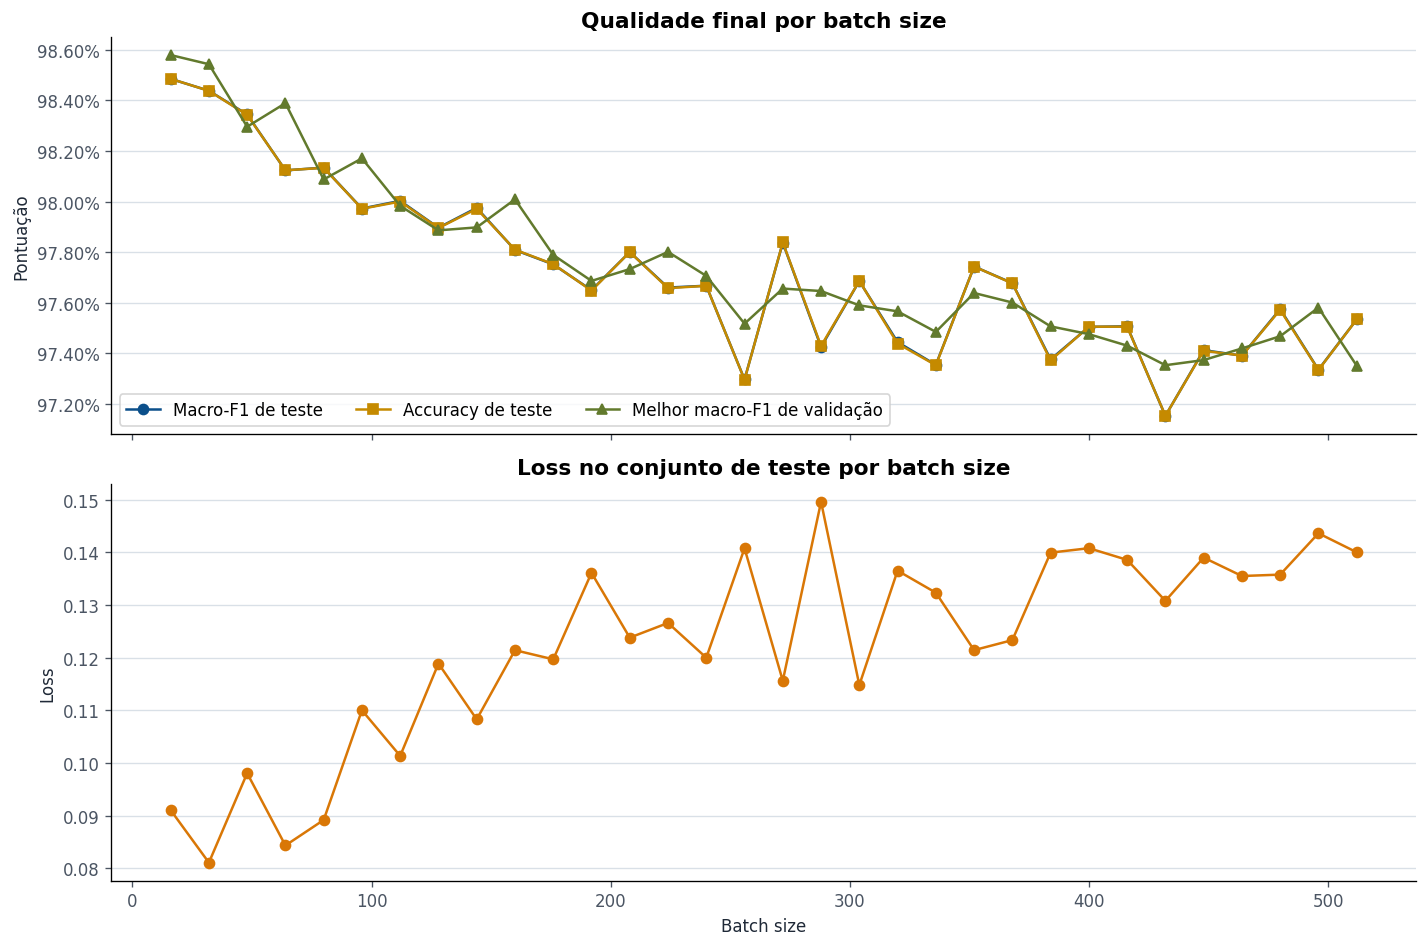

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
batch = runs["batch_size"]

axes[0].plot(batch, runs["test_macro_f1"], marker="o", color=BLUE, label="Macro-F1 de teste")
axes[0].plot(batch, runs["test_accuracy"], marker="s", color=GOLD, label="Accuracy de teste")
axes[0].plot(batch, runs["best_val_macro_f1"], marker="^", color=OLIVE, label="Melhor macro-F1 de validação")
axes[0].set_title("Qualidade final por batch size")
axes[0].set_ylabel("Pontuação")
axes[0].legend(ncol=3, loc="lower left")
style_axis(axes[0], percent=True)

axes[1].plot(batch, runs["test_loss"], marker="o", color=ORANGE)
axes[1].set_title("Loss no conjunto de teste por batch size")
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("Loss")
style_axis(axes[1])
finish_figure(fig, "01_quality_by_batch")

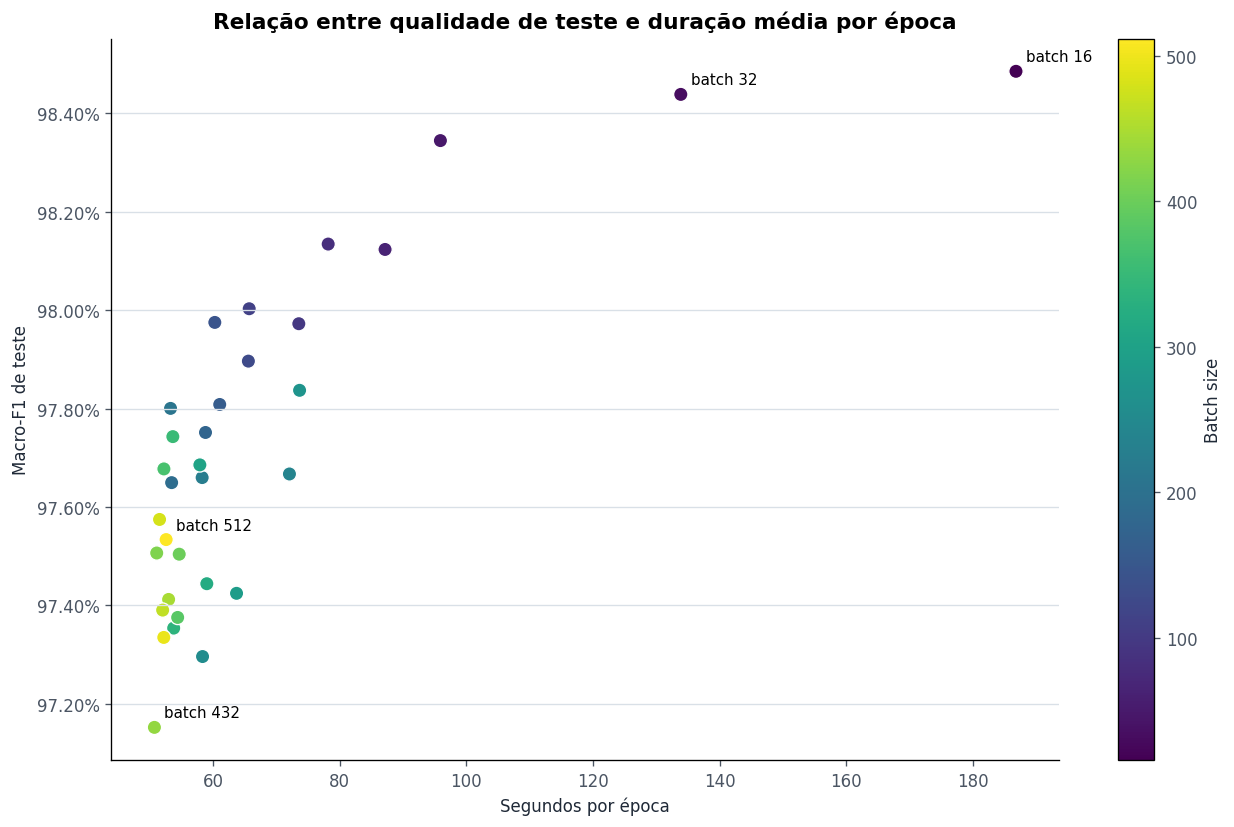

In [4]:
fig, axis = plt.subplots(figsize=(11, 7))
scatter = axis.scatter(
    runs["mean_epoch_seconds_recorded"],
    runs["test_macro_f1"],
    c=runs["batch_size"],
    cmap="viridis",
    s=74,
    edgecolor="white",
    linewidth=0.8,
)
for selected_batch in (16, 32, 432, 512):
    row = runs.loc[runs["batch_size"] == selected_batch].iloc[0]
    axis.annotate(
        f"batch {selected_batch}",
        (row["mean_epoch_seconds_recorded"], row["test_macro_f1"]),
        xytext=(6, 6), textcoords="offset points", fontsize=9,
    )
axis.set_title("Relação entre qualidade de teste e duração média por época")
axis.set_xlabel("Segundos por época")
axis.set_ylabel("Macro-F1 de teste")
style_axis(axis, percent=True)
colorbar = fig.colorbar(scatter, ax=axis)
colorbar.set_label("Batch size")
finish_figure(fig, "02_quality_vs_epoch_time")

## Resultados — tempo, throughput e eficiência

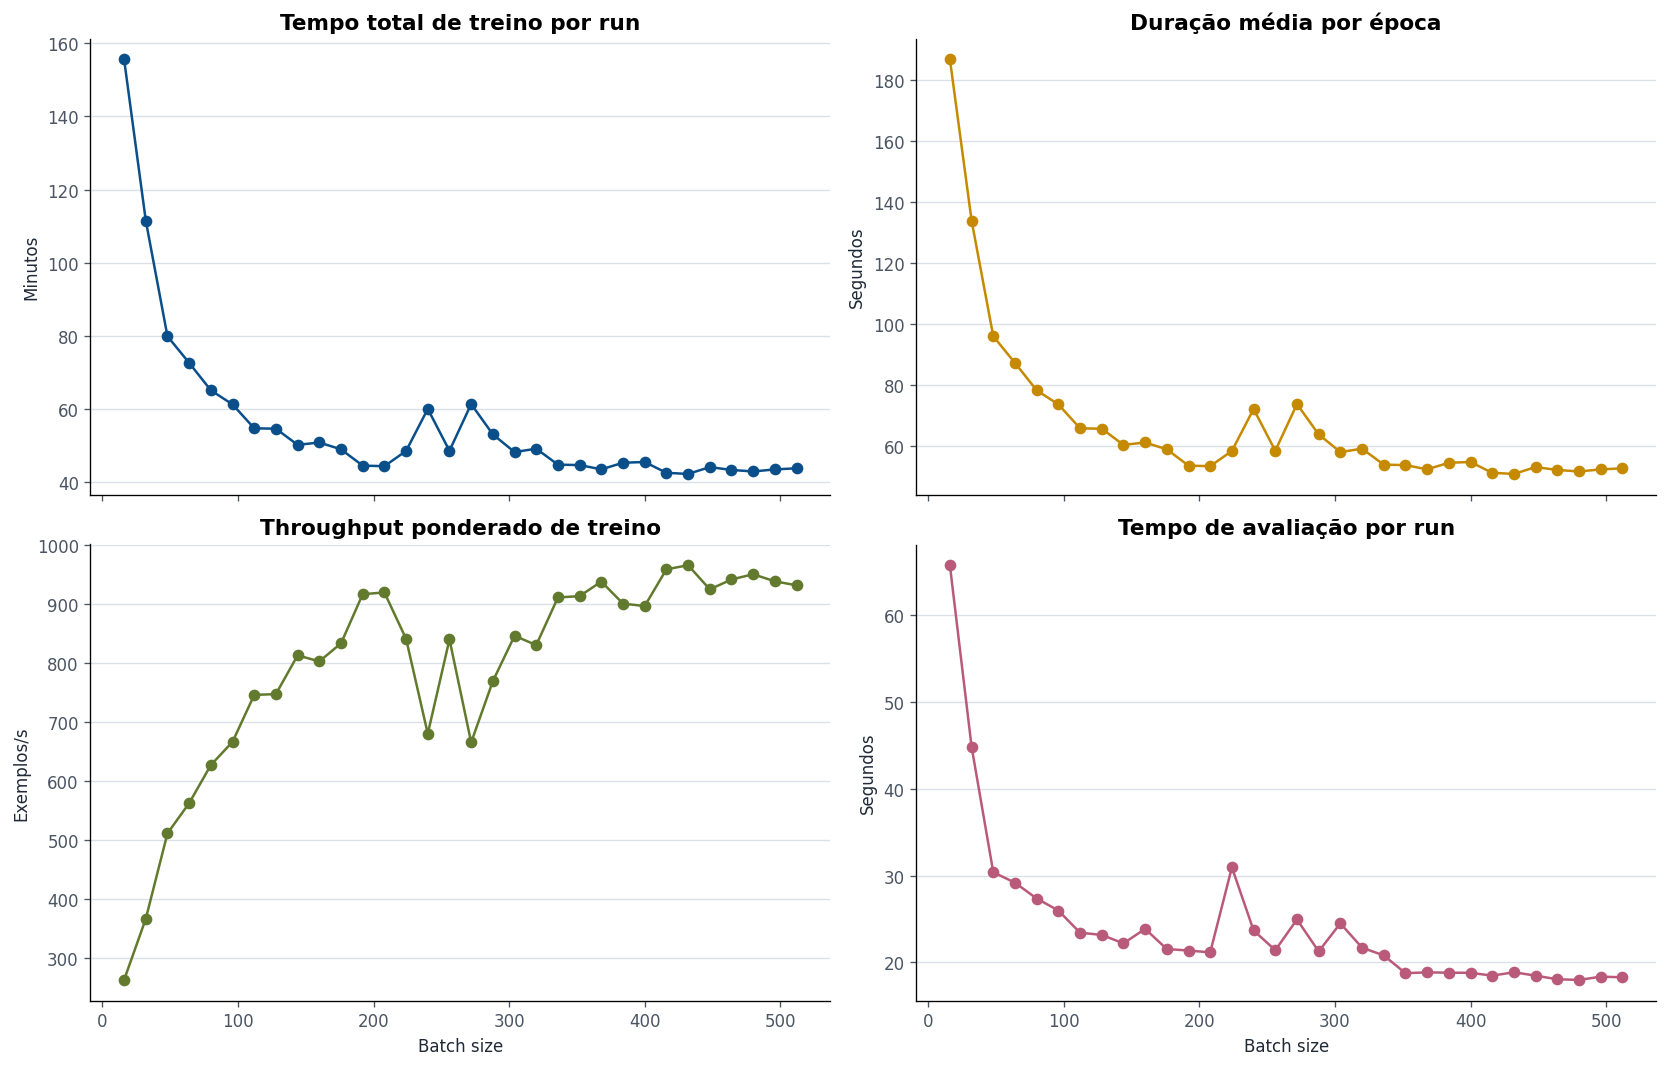

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

axes[0, 0].plot(batch, runs["training_seconds_recorded"] / 60, marker="o", color=BLUE)
axes[0, 0].set_title("Tempo total de treino por run")
axes[0, 0].set_ylabel("Minutos")
style_axis(axes[0, 0])

axes[0, 1].plot(batch, runs["mean_epoch_seconds_recorded"], marker="o", color=GOLD)
axes[0, 1].set_title("Duração média por época")
axes[0, 1].set_ylabel("Segundos")
style_axis(axes[0, 1])

axes[1, 0].plot(batch, runs["weighted_examples_per_second"], marker="o", color=OLIVE)
axes[1, 0].set_title("Throughput ponderado de treino")
axes[1, 0].set_xlabel("Batch size")
axes[1, 0].set_ylabel("Exemplos/s")
style_axis(axes[1, 0])

axes[1, 1].plot(batch, runs["evaluation_seconds"], marker="o", color=PINK)
axes[1, 1].set_title("Tempo de avaliação por run")
axes[1, 1].set_xlabel("Batch size")
axes[1, 1].set_ylabel("Segundos")
style_axis(axes[1, 1])
finish_figure(fig, "03_time_and_throughput")

## Resultados — uso de hardware

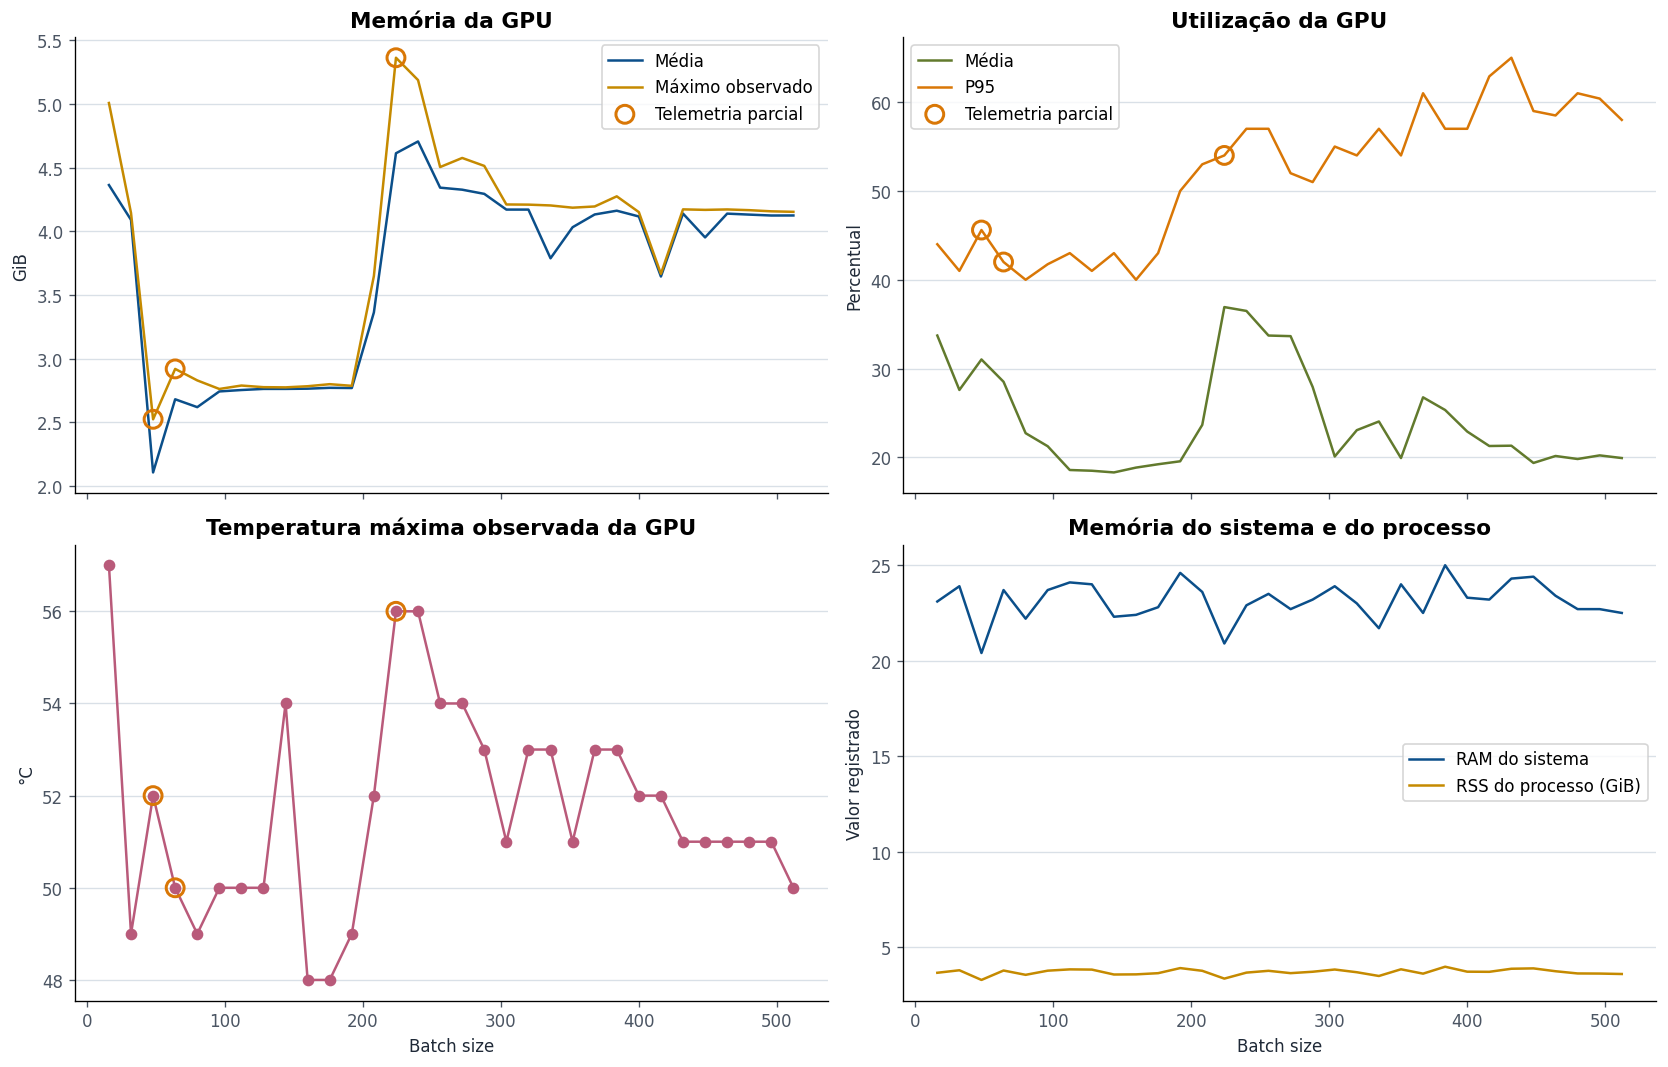

In [6]:
partial_batches = set(caveats.loc[caveats["issue"].str.contains("telemetria", case=False), "batch_size"])

def mark_partial(axis, x, y):
    values = hardware.loc[hardware["batch_size"].isin(partial_batches)]
    axis.scatter(values[x], values[y], s=115, facecolors="none", edgecolors=ORANGE,
                 linewidths=1.8, zorder=4, label="Telemetria parcial")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

axes[0, 0].plot(hardware["batch_size"], hardware["gpu_memory_mean_gib"], color=BLUE, label="Média")
axes[0, 0].plot(hardware["batch_size"], hardware["gpu_memory_max_gib"], color=GOLD, label="Máximo observado")
mark_partial(axes[0, 0], "batch_size", "gpu_memory_max_gib")
axes[0, 0].set_title("Memória da GPU")
axes[0, 0].set_ylabel("GiB")
axes[0, 0].legend()
style_axis(axes[0, 0])

axes[0, 1].plot(hardware["batch_size"], hardware["gpu_util_mean_percent"], color=OLIVE, label="Média")
axes[0, 1].plot(hardware["batch_size"], hardware["gpu_util_p95_percent"], color=ORANGE, label="P95")
mark_partial(axes[0, 1], "batch_size", "gpu_util_p95_percent")
axes[0, 1].set_title("Utilização da GPU")
axes[0, 1].set_ylabel("Percentual")
axes[0, 1].legend()
style_axis(axes[0, 1])

axes[1, 0].plot(hardware["batch_size"], hardware["gpu_temperature_max_c"], color=PINK, marker="o")
mark_partial(axes[1, 0], "batch_size", "gpu_temperature_max_c")
axes[1, 0].set_title("Temperatura máxima observada da GPU")
axes[1, 0].set_xlabel("Batch size")
axes[1, 0].set_ylabel("°C")
style_axis(axes[1, 0])

axes[1, 1].plot(hardware["batch_size"], hardware["ram_max_percent"], color=BLUE, label="RAM do sistema")
axes[1, 1].plot(hardware["batch_size"], hardware["process_rss_max_gib"], color=GOLD, label="RSS do processo (GiB)")
axes[1, 1].set_title("Memória do sistema e do processo")
axes[1, 1].set_xlabel("Batch size")
axes[1, 1].set_ylabel("Valor registrado")
axes[1, 1].legend()
style_axis(axes[1, 1])
finish_figure(fig, "04_hardware_by_batch")

## Resultados — curvas de convergência das 1.600 épocas

/tmp/ipykernel_415/1069539467.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


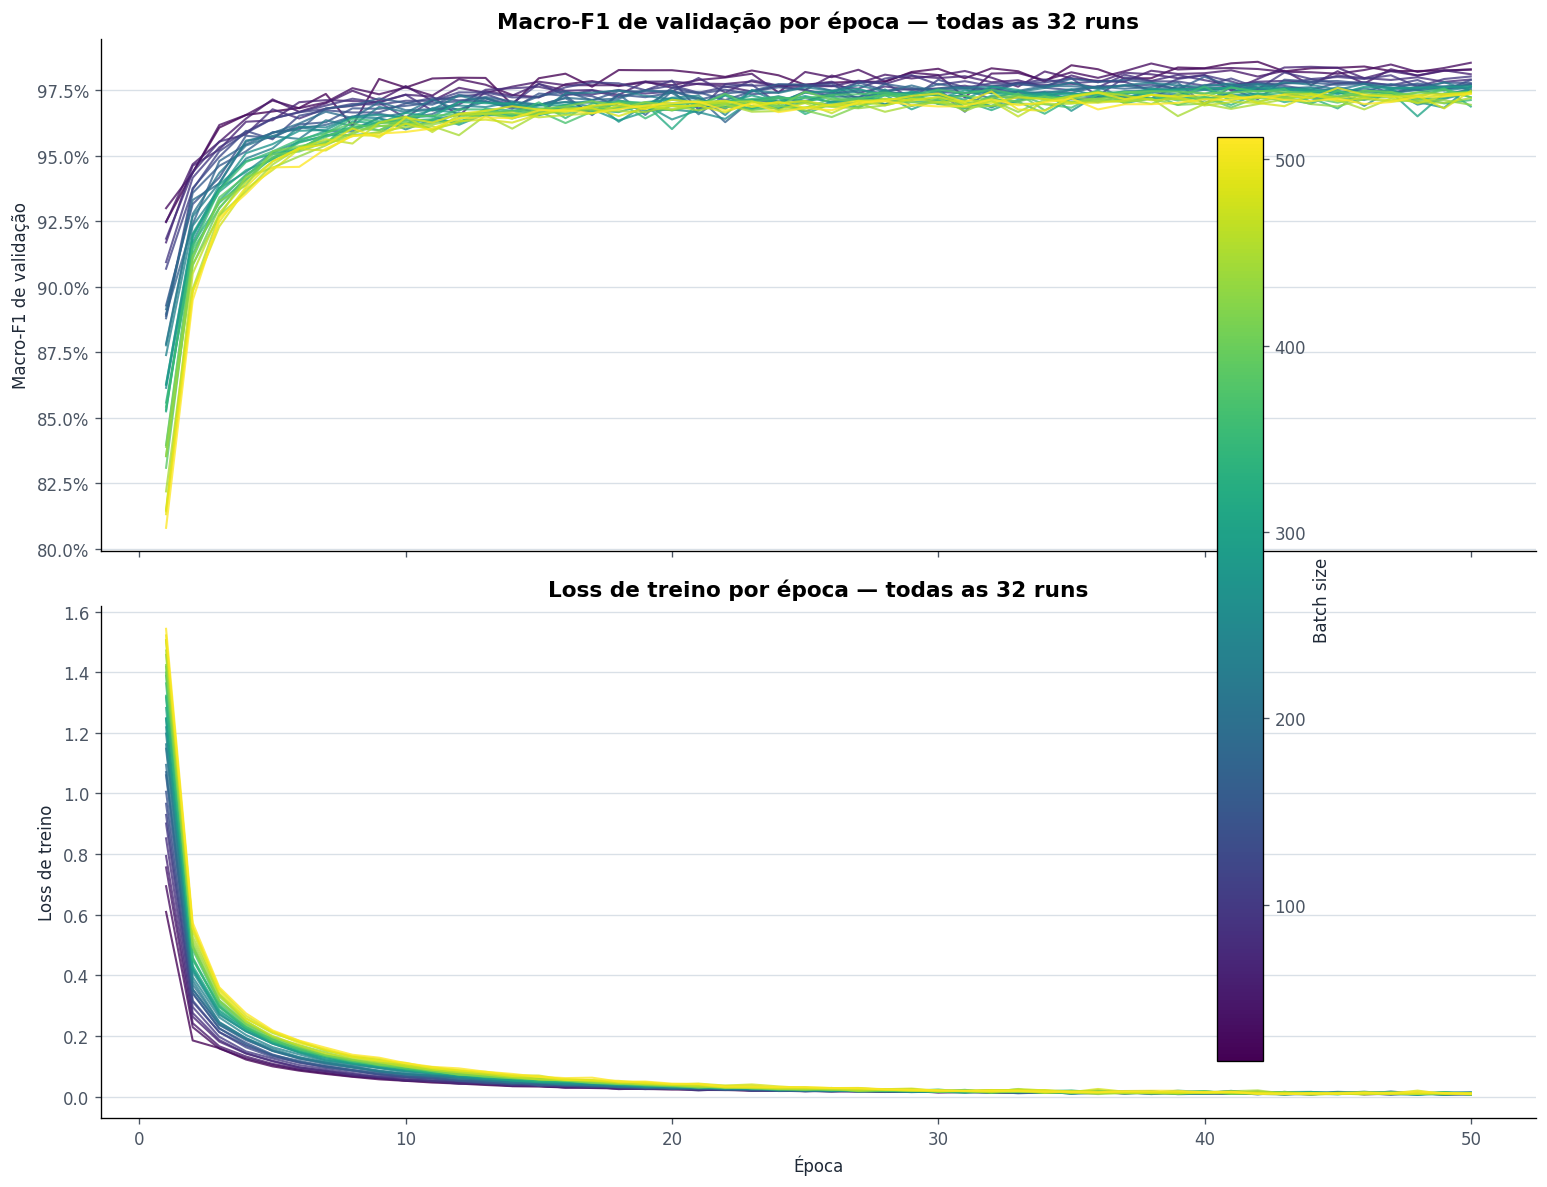

In [7]:
norm = Normalize(vmin=epochs["batch_size"].min(), vmax=epochs["batch_size"].max())
cmap = plt.colormaps["viridis"]
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

for current_batch, frame in epochs.groupby("batch_size", sort=True):
    color = cmap(norm(current_batch))
    axes[0].plot(frame["epoch"], frame["val_macro_f1"], color=color, alpha=0.78, linewidth=1.25)
    axes[1].plot(frame["epoch"], frame["loss"], color=color, alpha=0.78, linewidth=1.25)

axes[0].set_title("Macro-F1 de validação por época — todas as 32 runs")
axes[0].set_ylabel("Macro-F1 de validação")
style_axis(axes[0], percent=True)
axes[1].set_title("Loss de treino por época — todas as 32 runs")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss de treino")
style_axis(axes[1])
colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, pad=0.02)
colorbar.set_label("Batch size")
finish_figure(fig, "05_all_epoch_curves")

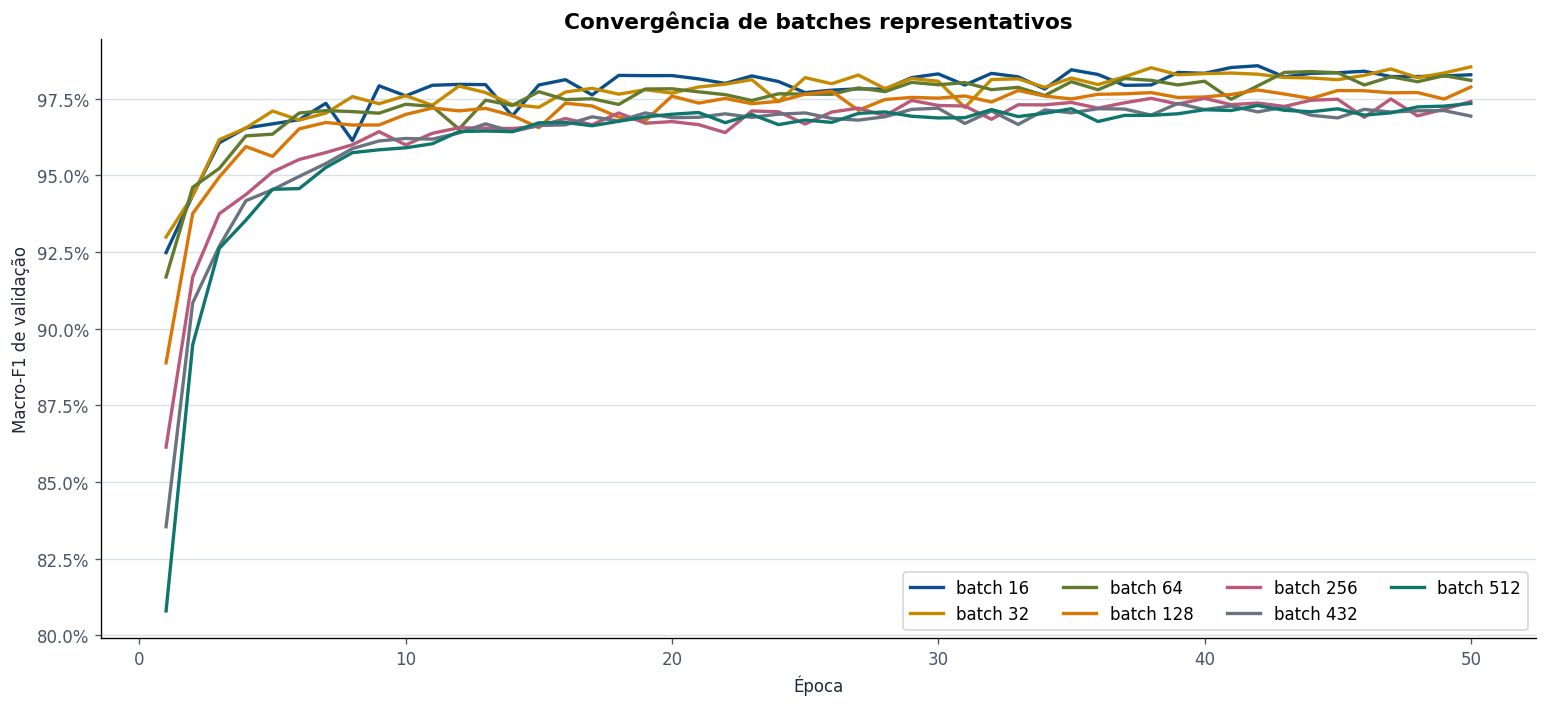

In [8]:
selected_batches = [16, 32, 64, 128, 256, 432, 512]
selected = epochs[epochs["batch_size"].isin(selected_batches)]
fig, axis = plt.subplots(figsize=(13, 6))
selected_palette = [BLUE, GOLD, OLIVE, ORANGE, PINK, "#6B7280", "#0F766E"]
for current_batch, color in zip(selected_batches, selected_palette):
    frame = selected[selected["batch_size"] == current_batch]
    axis.plot(frame["epoch"], frame["val_macro_f1"], label=f"batch {current_batch}", color=color, linewidth=2)
axis.set_title("Convergência de batches representativos")
axis.set_xlabel("Época")
axis.set_ylabel("Macro-F1 de validação")
axis.legend(ncol=4, loc="lower right")
style_axis(axis, percent=True)
finish_figure(fig, "06_selected_convergence")

## Resultados — métricas por classe

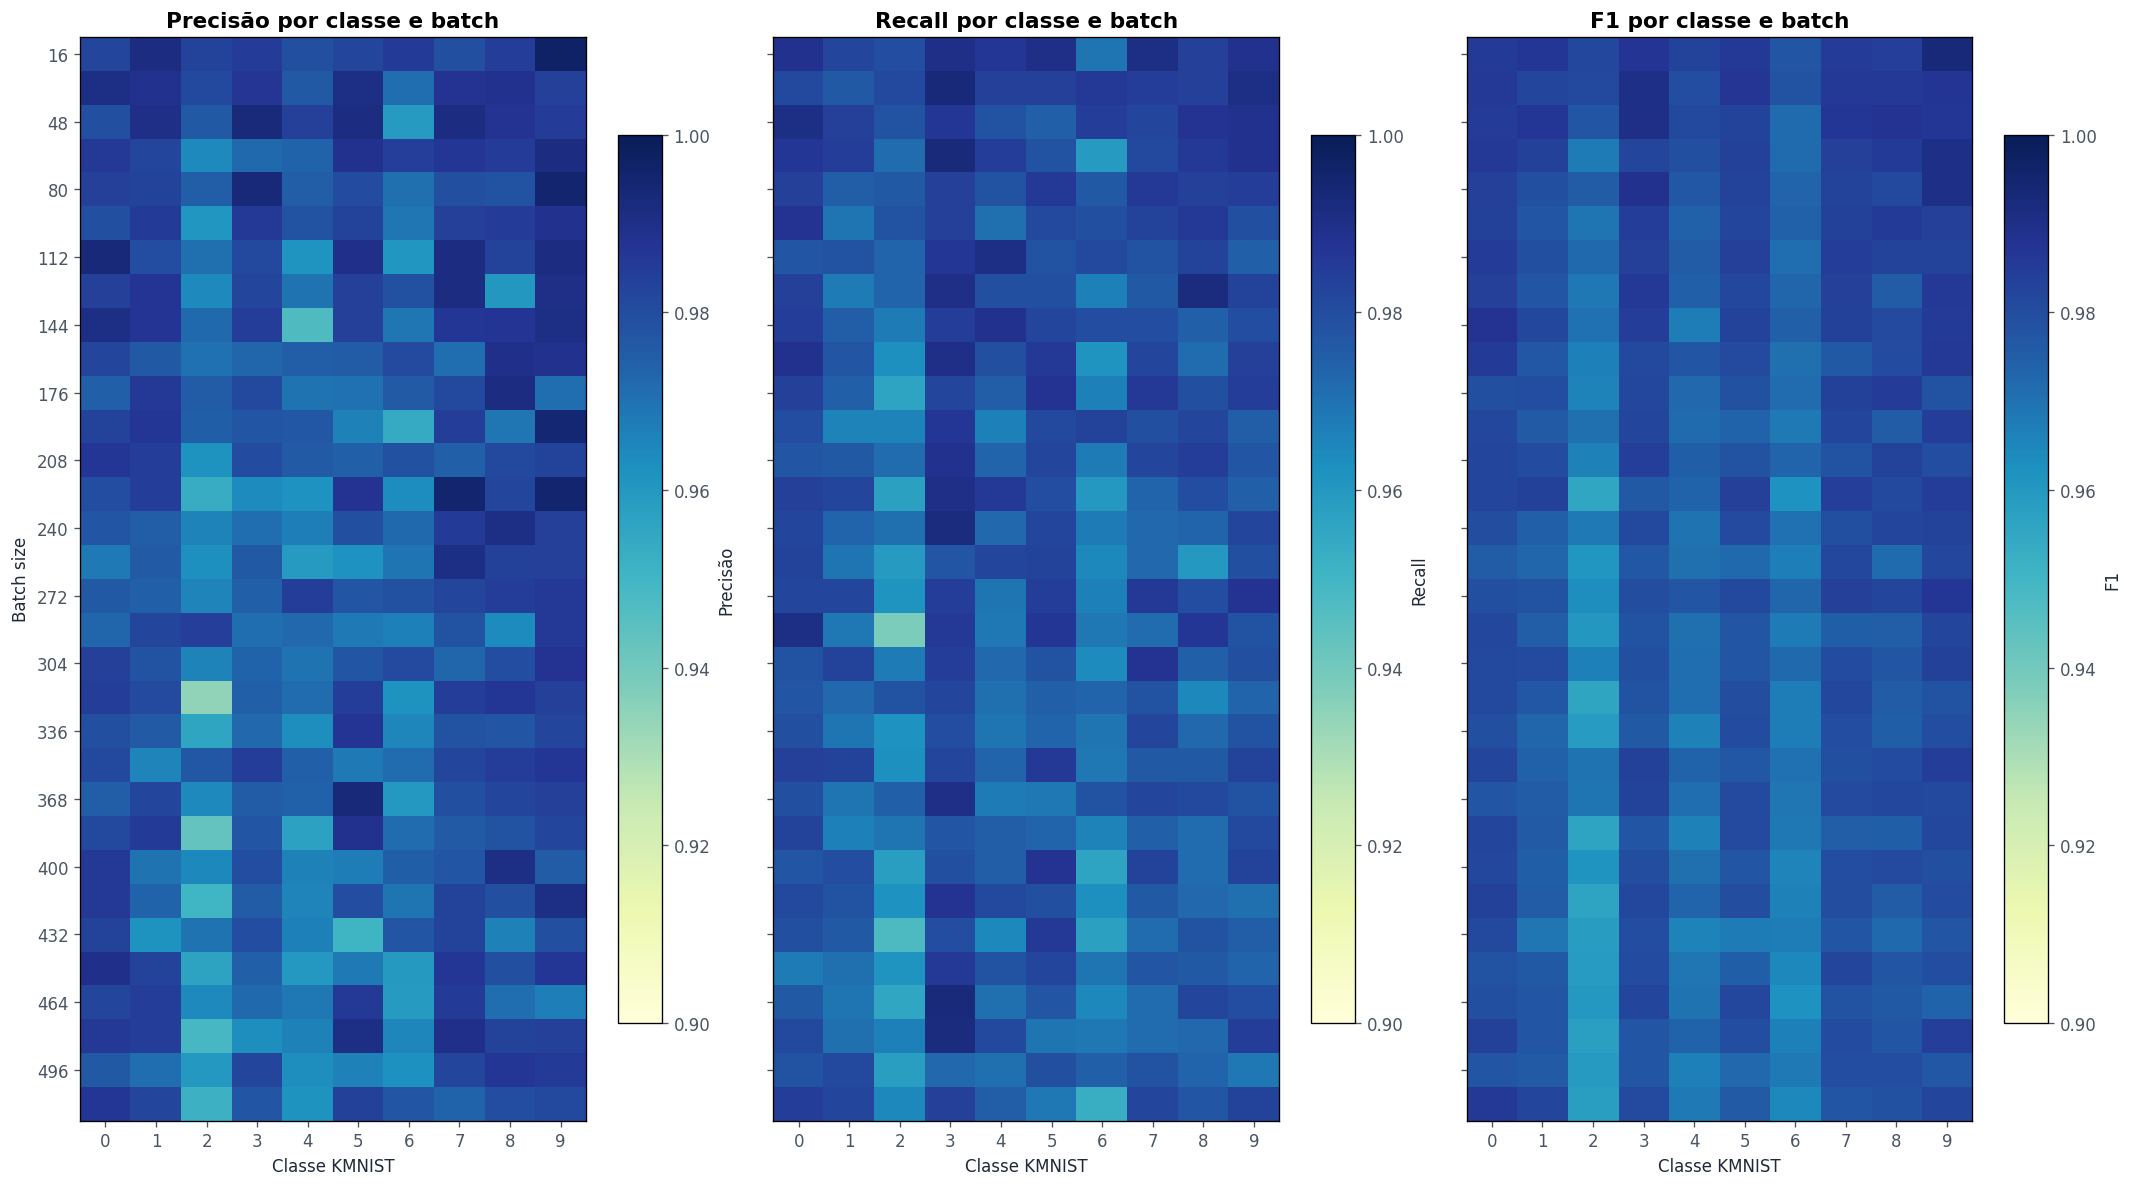

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
metrics_to_plot = [("precision", "Precisão"), ("recall", "Recall"), ("f1", "F1")]
ordered_batches = sorted(class_metrics["batch_size"].unique())
ordered_classes = sorted(class_metrics["class_id"].unique())

for axis, (metric, title) in zip(axes, metrics_to_plot):
    matrix = class_metrics.pivot(index="batch_size", columns="class_id", values=metric)
    image = axis.imshow(matrix.loc[ordered_batches, ordered_classes], aspect="auto", cmap="YlGnBu", vmin=0.90, vmax=1.00)
    axis.set_title(f"{title} por classe e batch")
    axis.set_xlabel("Classe KMNIST")
    axis.set_xticks(range(len(ordered_classes)), ordered_classes)
    axis.set_yticks(range(0, len(ordered_batches), 2), ordered_batches[::2])
    if axis is axes[0]:
        axis.set_ylabel("Batch size")
    fig.colorbar(image, ax=axis, shrink=0.82, label=title)
finish_figure(fig, "07_class_metric_heatmaps")

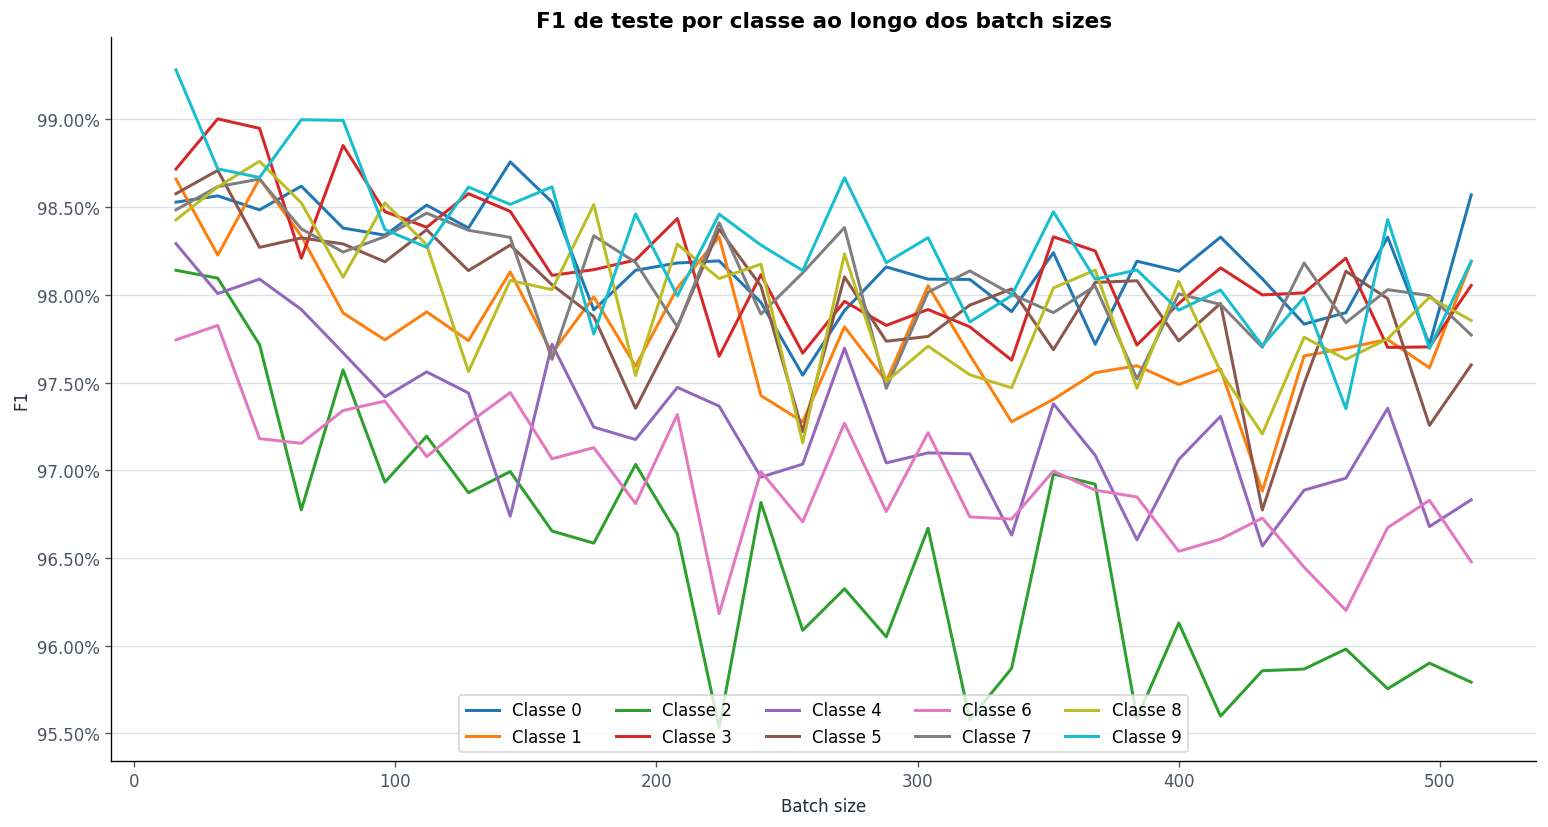

In [10]:
class_f1 = class_metrics.pivot(index="batch_size", columns="class_id", values="f1")
fig, axis = plt.subplots(figsize=(13, 7))
class_colors = plt.colormaps["tab10"].colors
for class_id in class_f1.columns:
    axis.plot(class_f1.index, class_f1[class_id], label=f"Classe {class_id}", color=class_colors[int(class_id)], linewidth=1.8)
axis.set_title("F1 de teste por classe ao longo dos batch sizes")
axis.set_xlabel("Batch size")
axis.set_ylabel("F1")
axis.legend(ncol=5, loc="lower center")
style_axis(axis, percent=True)
finish_figure(fig, "08_class_f1_lines")

## Tabelas completas por run e ressalvas

In [11]:
complete_table = (
    runs.merge(hardware, on="batch_size", how="left", validate="one_to_one")
    .sort_values("batch_size")
    [[
        "batch_size", "test_accuracy", "test_macro_f1", "test_loss",
        "best_epoch", "best_val_macro_f1", "training_seconds_recorded",
        "mean_epoch_seconds_recorded", "weighted_examples_per_second",
        "evaluation_seconds", "gpu_memory_max_gib", "gpu_temperature_max_c",
        "gpu_util_mean_percent", "ram_max_percent", "telemetry_coverage_rate",
    ]]
)
display(complete_table)
display(caveats)

,batch_size,test_accuracy,test_macro_f1,test_loss,best_epoch,best_val_macro_f1,training_seconds_recorded,mean_epoch_seconds_recorded,weighted_examples_per_second,evaluation_seconds,gpu_memory_max_gib,gpu_temperature_max_c,gpu_util_mean_percent,ram_max_percent,telemetry_coverage_rate
0,16,0.9849,0.9849,0.0911,42,0.9858,"9,339.0678",186.7814,262.3388,65.7787,5.0089,57.0000,33.7229,23.1000,0.9800
1,32,0.9844,0.9844,0.0811,50,0.9854,"6,692.6405",133.8528,366.0737,44.8621,4.1447,49.0000,27.5952,23.9000,1.0000
2,48,0.9834,0.9834,0.0981,47,0.9830,"4,794.6719",95.8934,510.9839,30.3895,2.5236,52.0000,31.0275,20.4000,0.0800
3,64,0.9812,0.9812,0.0844,44,0.9839,"4,357.7814",87.1556,562.2127,29.1929,2.9195,50.0000,28.5162,23.7000,0.8200
4,80,0.9813,0.9813,0.0892,37,0.9809,"3,908.6473",78.1729,626.8153,27.3664,2.8293,49.0000,22.7279,22.2000,1.0000
5,96,0.9797,0.9797,0.1100,43,0.9817,"3,676.8050",73.5361,666.3394,25.9867,2.7620,50.0000,21.2570,23.7000,1.0000
6,112,0.9800,0.9800,0.1014,37,0.9798,"3,285.0902",65.7018,745.7938,23.4225,2.7889,50.0000,18.5816,24.1000,1.0000
7,128,0.9790,0.9790,0.1189,50,0.9789,"3,278.5809",65.5716,747.2745,23.1759,2.7761,50.0000,18.4982,24.0000,1.0000
8,144,0.9797,0.9798,0.1083,43,0.9790,"3,013.6345",60.2727,812.9718,22.1989,2.7745,54.0000,18.3082,22.3000,1.0000
9,160,0.9781,0.9781,0.1214,40,0.9801,"3,052.3606",61.0472,802.6575,23.8677,2.7834,48.0000,18.8525,22.4000,1.0000


,batch_size,issue,severity,evidence,implication
0,48,Cobertura parcial de telemetria,Média para hardware; baixa para qualidade do m...,4/50 eventos epoch_end,Picos observados não representam necessariamen...
1,64,Cobertura parcial de telemetria,Média para hardware; baixa para qualidade do m...,41/50 eventos epoch_end,Picos observados não representam necessariamen...
2,224,Cobertura parcial de telemetria,Média para hardware; baixa para qualidade do m...,7/50 eventos epoch_end,Picos observados não representam necessariamen...


## Conclusões e próximos passos

In [12]:
best_quality = runs.loc[runs["test_macro_f1"].idxmax()]
fastest = runs.loc[runs["mean_epoch_seconds_recorded"].idxmin()]
batch_32 = runs.loc[runs["batch_size"] == 32].iloc[0]
batch_16 = runs.loc[runs["batch_size"] == 16].iloc[0]

speed_gain_32 = 1 - batch_32["mean_epoch_seconds_recorded"] / batch_16["mean_epoch_seconds_recorded"]
f1_gap_32 = best_quality["test_macro_f1"] - batch_32["test_macro_f1"]

print(f"Maior macro-F1: batch {int(best_quality.batch_size)} — {best_quality.test_macro_f1:.4%}")
print(f"Mais rápido: batch {int(fastest.batch_size)} — {fastest.mean_epoch_seconds_recorded:.2f} s/época e {fastest.weighted_examples_per_second:.2f} exemplos/s")
print(f"Batch 32 vs. batch 16: {speed_gain_32:.1%} menos tempo/época e diferença de {f1_gap_32:.4%} em macro-F1.")
print("Recomendação: repetir batches candidatos em pelo menos três seeds antes de fixar o batch de produção.")

Maior macro-F1: batch 16 — 98.4855%
Mais rápido: batch 432 — 50.73 s/época e 965.81 exemplos/s
Batch 32 vs. batch 16: 28.3% menos tempo/época e diferença de 0.0469% em macro-F1.
Recomendação: repetir batches candidatos em pelo menos três seeds antes de fixar o batch de produção.
